In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## New Plots

In [10]:
training_times = {
    'cart_pole': 4_000_000,
    'mini_grid': 500_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 15_000_000,
}

gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 30_000_000,
}

name_to_nice = {
    'cart_pole': "CartPole",
    'mini_grid': "MiniGrid",
    'glucose': 'Glucose',
    'pong': "Pong",
    'boxing': "Boxing"
}

methods_to_nice = {
    'random': 'Random',
    'entropy': 'Variance',
    'greedy': 'Greedy',
    'lp_hybrid': "CSA",
}

methods_dict = {
    0: 'Random',
    1: 'Variance',
    2: 'Greedy',
    3: 'CSA',
    
}

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

method_scales = [lambda d: d/500*100, lambda d: d/1*100, lambda d: (d+21)/42*100, lambda d: d/100*100, lambda d: (d+20)/(55+20)*100]

In [11]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","random","entropy","greedy","lp_hybrid"]

all_performances_perfect = []
all_performances_imperfect = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)
    all_performances_perfect.append(temp)

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        if m == 'multiple':
            print("Environment",e,[i['concept_accuracy'] for i in matching_params])

    all_performances_imperfect.append(temp)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison', 'method': 'ground_truth'})
    m = 'ground_truth'
    print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed']) for i in matching_params if m in i])
    performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
    all_baselines.append(performance)
all_baselines.append(0)

Perfect cart_pole perfect_concepts 3 [(499.5, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.875, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.915, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole random 3 [(173.9106830122592, 44, [0, 9, 10]), (171.32413793103447, 42, [0, 9, 10]), (172.8411867364747, 43, [0, 9, 10])]
Perfect cart_pole entropy 3 [(104.6621052631579, 44, [3, 0, 9]), (105.5270413573701, 42, [3, 0, 9]), (106.8741935483871, 43, [3, 0, 9])]
Perfect cart_pole greedy 3 [(164.65671641791045, 44, [9, 10, 11]), (163.0935960591133, 43, [9, 10, 11]), (167.53807106598984, 42, [9, 10, 11])]
Perfect cart_pole lp_hybrid 3 [(204.00821355236138, 42, [1, 4, 7]), (413.1386554621849, 44, [1, 7, 10]), (381.36293436293437, 43, [0, 6, 10])]
Perfect mini_grid perfect_concepts 3 [(0.9595455418019246, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]), (0.

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


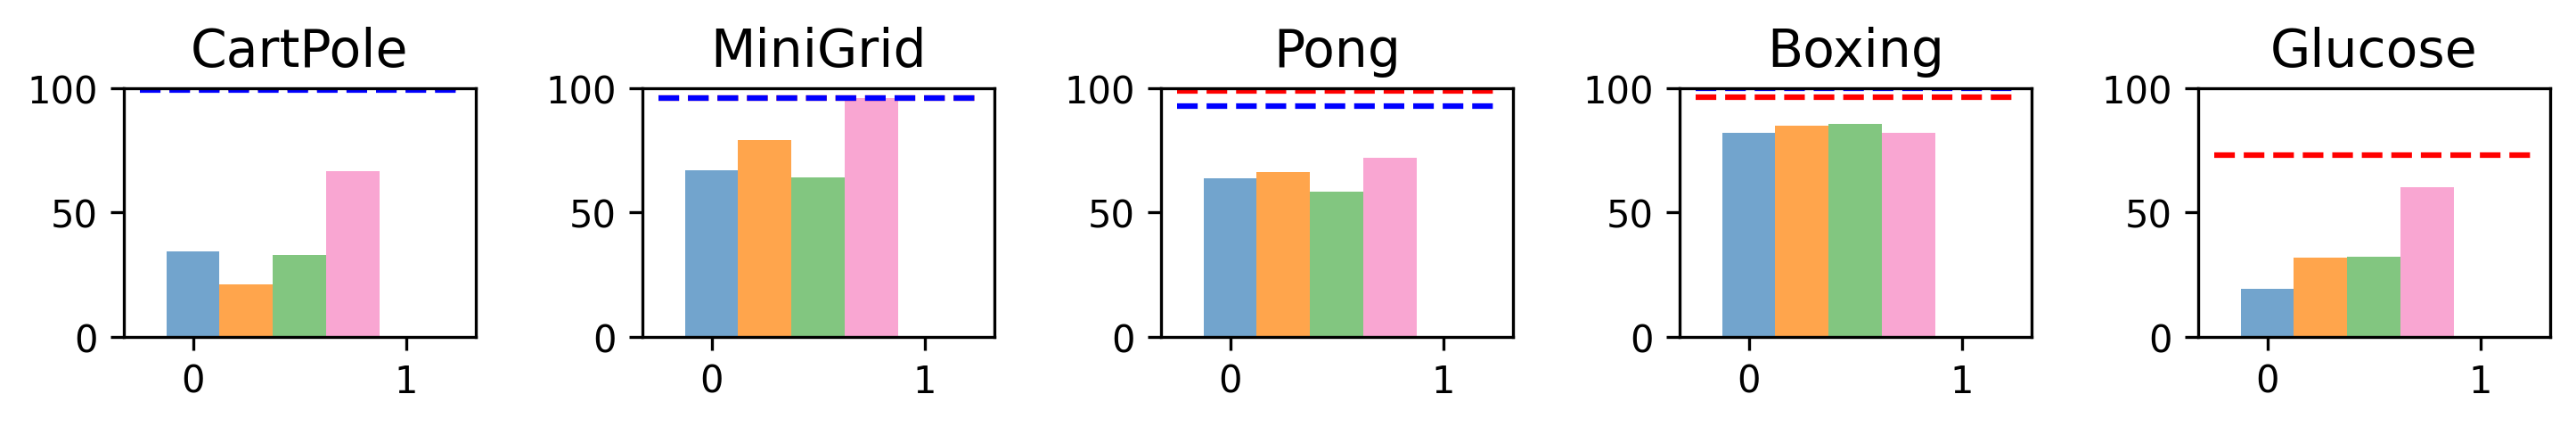

In [12]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect[i][:-1])))
    y_vals = all_performances_perfect[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_perfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_perfect.pdf",dpi=300, bbox_inches='tight')

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


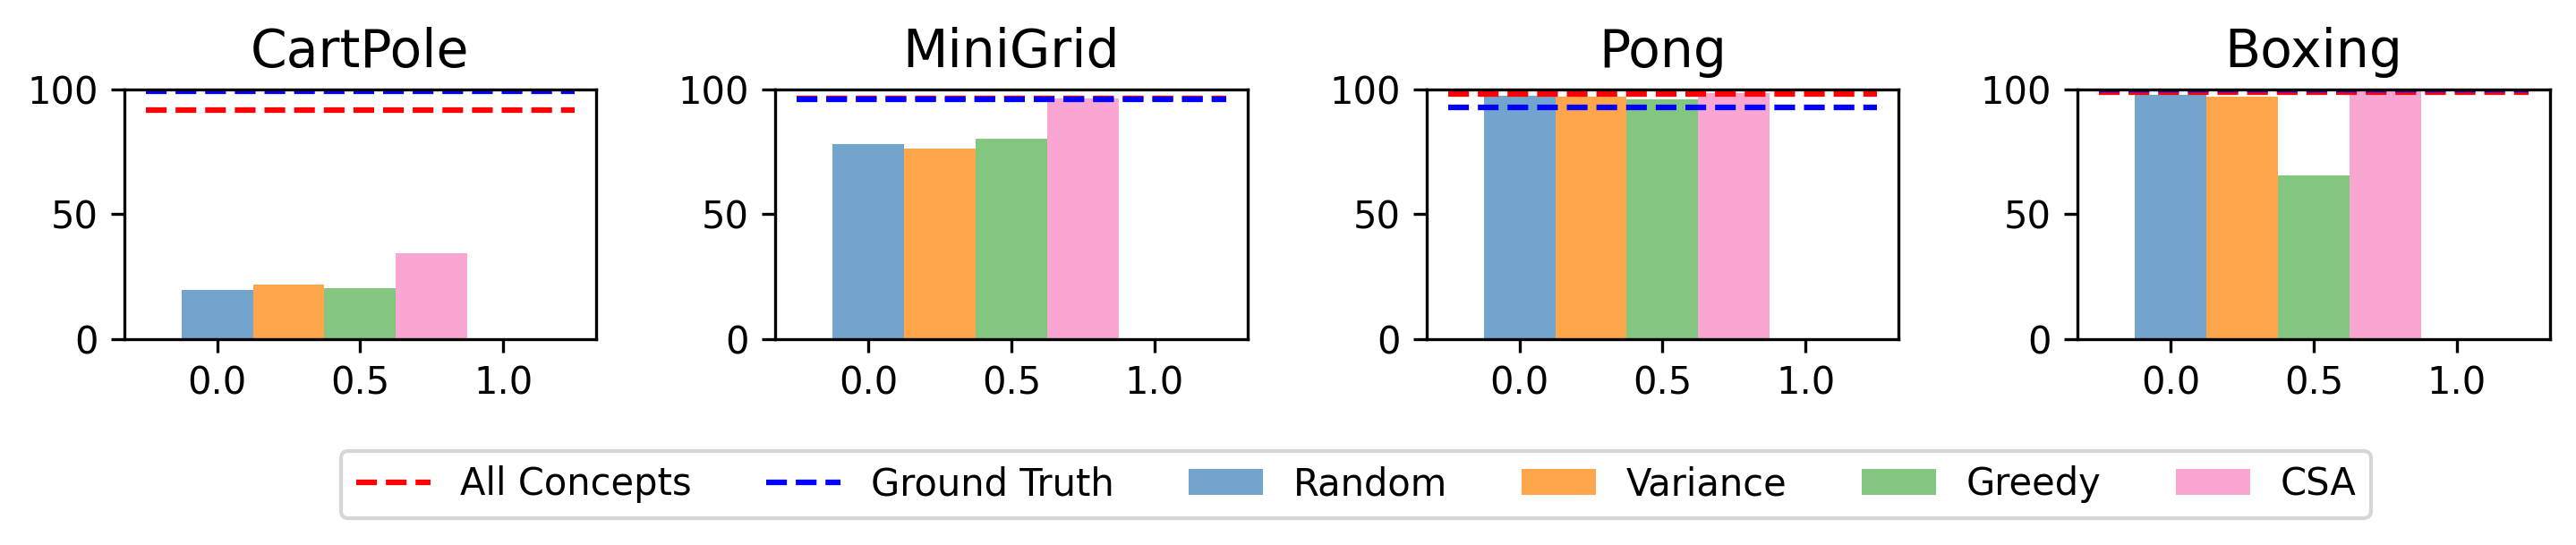

In [16]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect[i][:-1])))
    y_vals = all_performances_imperfect[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_imperfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.14,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect.pdf",dpi=300, bbox_inches='tight')

In [17]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
for j,e in enumerate(perfect_environments):
    temp_env = []
    for m in perfect_methods:
        temp = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e],'experiment': 'perfect_comparison'})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'perfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)
        temp_env.append(temp)
    all_performances_k.append(temp_env)


Perfect cart_pole random 1 [112.26727066817666, 112.20744081172492, 112.21468926553672] 1.0
Perfect cart_pole random 2 [164.70364238410596, 164.03471074380164, 165.74376039933443] 2.0
Perfect cart_pole random 3 [173.9106830122592, 171.32413793103447, 172.8411867364747] 3.0
Perfect cart_pole entropy 1 [39.99559647718174, 40.17538213998391, 112.26727066817666] 1.0
Perfect cart_pole entropy 2 [110.55937846836848, 113.44697833523375, 41.23347107438016] 2.0
Perfect cart_pole entropy 3 [104.6621052631579, 105.5270413573701, 106.8741935483871] 3.0
Perfect cart_pole greedy 1 [112.21468926553672, 29.549141503848432, 112.26727066817666] 1.0
Perfect cart_pole greedy 2 [98.65609514370664, 112.54761904761905, 161.92659053833606] 2.0
Perfect cart_pole greedy 3 [164.65671641791045, 163.0935960591133, 167.53807106598984] 3.0
Perfect cart_pole lp_hybrid 1 [112.26727066817666, 112.20744081172492, 112.21468926553672] 1.0
Perfect cart_pole lp_hybrid 2 [328.1262458471761, 391.234126984127, 382.046511627906

[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[22.445960049695888, 32.965474235149465, 34.538400511984555], [12.829216619022818, 17.682655191865493, 21.137556011261005], [16.935406762504122, 24.875353648644115, 33.019225569534235], [22.445960049695888, 73.427125630614, 66.56732022516539]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[29.24421855200488, 41.17805743283458, 67.15678932106212], [16.53988316077532, 33.07323773038895, 79.33875041232935], [39.22079885880403, 45.94463828507055, 64.1841245020065], [36.114600810313256, 90.18613294363543, 96.01826604120718]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[7.0960679414517, 77.72657450076805, 63.87966763003531], [12.63577788839113, 29.183201058201057, 66.30168681892819], [15.135582010582013, 41.2799056820796, 58.51776618966772], [11.187484658185342, 50.11582915994681, 71.98273360971774]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[90.3240332930351, 75.65561456099776, 81.94008116237218], [77.60141267749964, 85.84661807161099, 84.

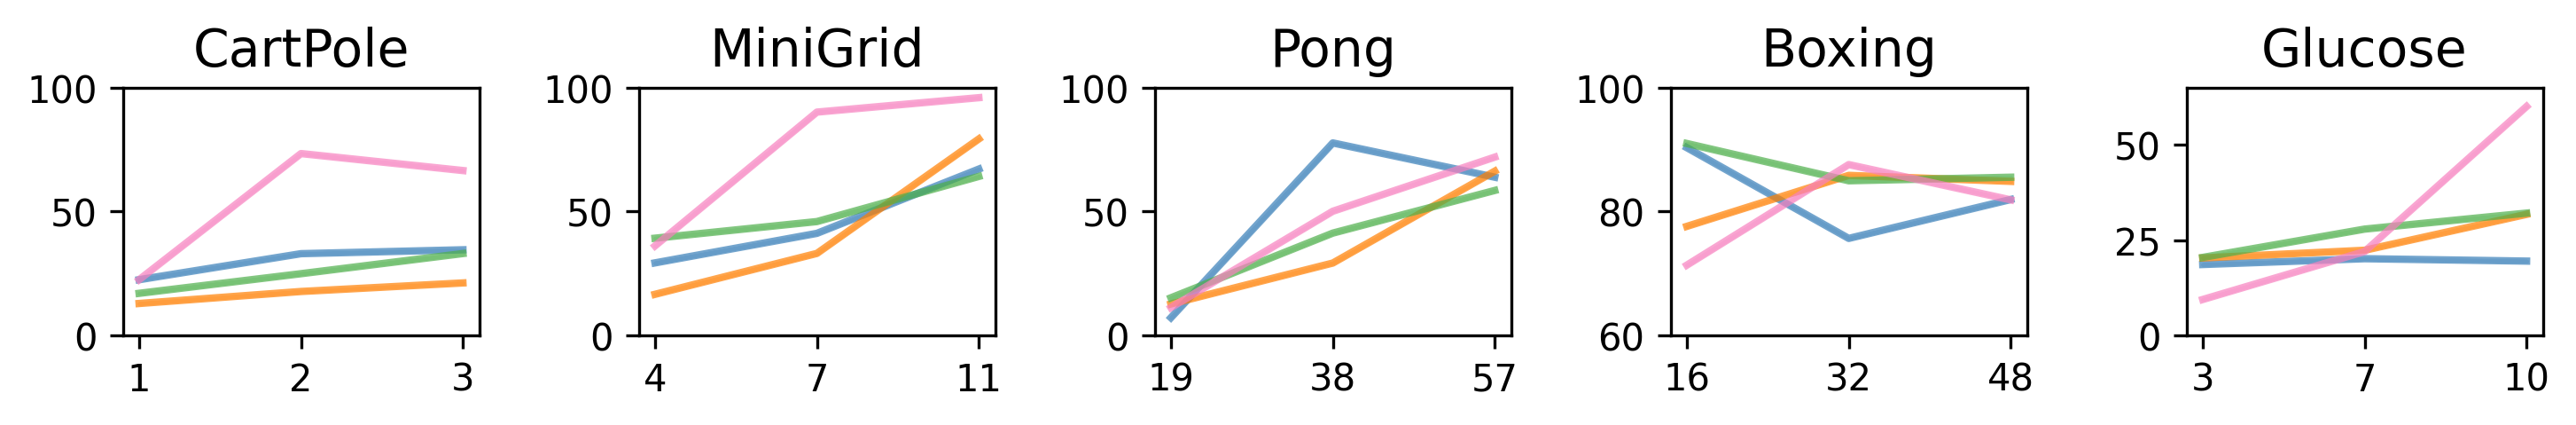

In [23]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,100],[60,100],[0,65]]],
    'x_ticks': [[[[0,1,2],[round(num_concepts_selected[perfect_environments[i]]*[0.33,0.66,1][j]) for j in range(3)]] for i in range(5)] for j in range(1)],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(perfect_environments)):
    y_vals = all_performances_k[i]

    x_groups = [list(range(len(j))) for j in y_vals]

    print(x_groups,y_vals)

    plot_line(ax[0][i],x_groups,y_vals,np.zeros(np.array(y_vals).shape), perfect_methods,line_format)
    
fig.savefig("../../results/figures/perfect_varied_k.pdf",dpi=300, bbox_inches='tight')

In [24]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
for j,e in enumerate(perfect_environments):
    temp_env = []
    for m in perfect_methods:
        temp = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e],'experiment': 'imperfect_comparison'})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'imperfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)
        temp_env.append(temp)
    all_performances_k.append(temp_env)


Perfect cart_pole random 1 [75.43149129447389, 81.05126118795769, 88.20726306465899] 1.0
Perfect cart_pole random 2 [89.7954954954955, 75.75930144267274, 83.8357203032856] 2.0
Perfect cart_pole random 3 [98.75992063492063, 93.12418300653594, 99.547] 3.0
Perfect cart_pole entropy 1 [75.43149129447389, 31.459553037456722, 33.078476821192055] 1.0
Perfect cart_pole entropy 2 [52.17425431711146, 92.26851851851852, 101.55816326530612] 2.0
Perfect cart_pole entropy 3 [101.40570846075433, 122.1116564417178, 103.90615224191866] 3.0
Perfect cart_pole greedy 1 [75.43149129447389, 81.05126118795769, 32.04201411161001] 1.0
Perfect cart_pole greedy 2 [75.33711262282691, 90.6287534121929, 82.6298755186722] 2.0
Perfect cart_pole greedy 3 [102.66323377960865, 98.20808678500987, 101.67755102040816] 3.0
Perfect cart_pole lp_hybrid 1 [75.43149129447389, 81.05126118795769, 88.20726306465899] 1.0
Perfect cart_pole lp_hybrid 2 [128.05791505791507, 89.44753363228699, 90.14751131221719] 2.0
Perfect cart_pole l

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Perfect glucose entropy 3 [] nan
Perfect glucose entropy 7 [] nan
Perfect glucose entropy 10 [] nan
Perfect glucose greedy 3 [] nan
Perfect glucose greedy 7 [] nan
Perfect glucose greedy 10 [] nan
Perfect glucose lp_hybrid 3 [] nan
Perfect glucose lp_hybrid 7 [] nan
Perfect glucose lp_hybrid 10 [] nan


[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[16.312667703139372, 16.62603448276359, 19.428740242763777], [9.331301410208177, 16.40006240672907, 21.82823447629272], [12.568317772936105, 16.573049436912797, 20.16992477233511], [16.312667703139372, 20.510197333494617, 34.14723190590428]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[55.963282065081884, 72.35441863478803, 78.09182852957318], [22.416756065122385, 35.70579555952446, 76.16603616945268], [42.48646473780956, 61.3084735590499, 80.1444226009258], [53.42832006556117, 93.69315331635842, 96.3253730047895]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[92.2551794188821, 98.92934446505875, 97.45661084946798], [91.26984126984125, 95.72094150361627, 96.89294157379264], [87.36551381712671, 97.35427271141558, 96.17011686194077], [99.0028394398695, 98.20575368194415, 98.43202432488147]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[97.9041557396696, 99.47933693941813, 97.78619568680102], [71.85717084808239, 89.38804020554369, 97.20844

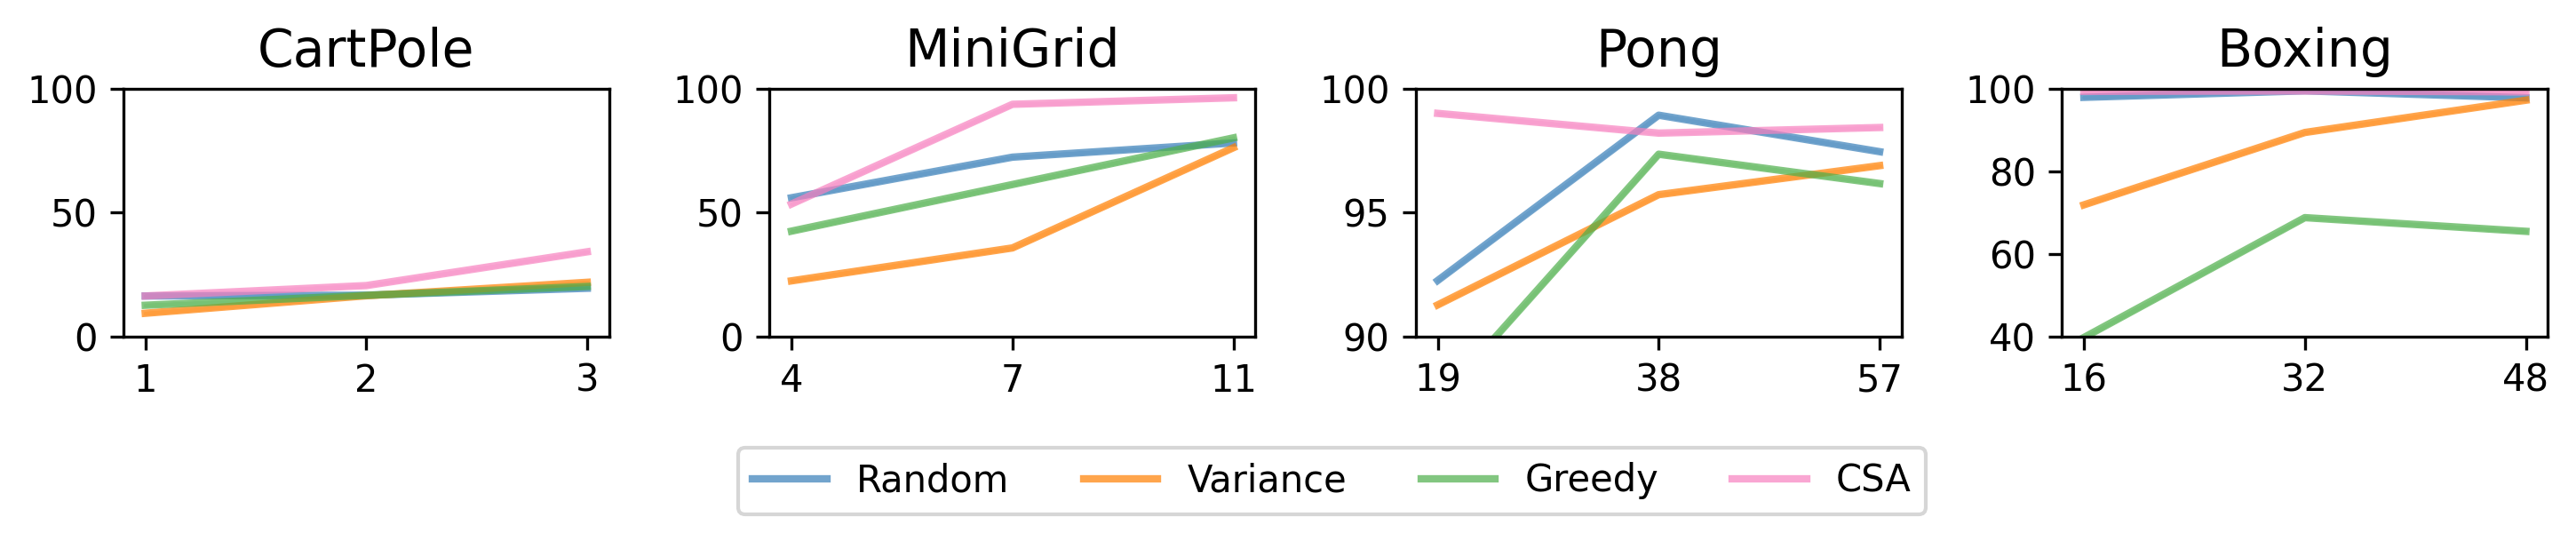

In [36]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[90,100],[40,100],[0,65]]],
    'x_ticks': [[[[0,1,2],[round(num_concepts_selected[imperfect_environments[i]]*[0.33,0.66,1][j]) for j in range(3)]] for i in range(4)] for j in range(1)],
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    y_vals = all_performances_k[i]

    x_groups = [list(range(len(j))) for j in y_vals]

    print(x_groups,y_vals)

    plot_line(ax[0][i],x_groups,y_vals,np.zeros(np.array(y_vals).shape), [methods_to_nice[m] for m in perfect_methods],line_format)
    
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.29,-0.1),'fontsize': 16}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_varied_k.pdf",dpi=300, bbox_inches='tight')

In [37]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
for j,e in enumerate(perfect_environments):
    temp_env = []
    for m in perfect_methods:
        temp = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e]})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'perfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)
        temp_env.append(temp)
    all_performances_k.append(temp_env)


Perfect cart_pole random 1 [112.26727066817666, 112.20744081172492, 75.43149129447389, 81.05126118795769, 112.21468926553672, 88.20726306465899] 1.0
Perfect cart_pole random 2 [164.70364238410596, 89.7954954954955, 164.03471074380164, 165.74376039933443, 75.75930144267274, 83.8357203032856] 2.0
Perfect cart_pole random 3 [173.9106830122592, 171.32413793103447, 172.8411867364747] 3.0
Perfect cart_pole entropy 1 [39.99559647718174, 75.43149129447389, 40.17538213998391, 112.26727066817666, 31.459553037456722, 33.078476821192055] 1.0
Perfect cart_pole entropy 2 [52.17425431711146, 110.55937846836848, 92.26851851851852, 113.44697833523375, 41.23347107438016, 101.55816326530612] 2.0
Perfect cart_pole entropy 3 [104.6621052631579, 105.5270413573701, 106.8741935483871] 3.0
Perfect cart_pole greedy 1 [112.21468926553672, 75.43149129447389, 81.05126118795769, 29.549141503848432, 32.04201411161001, 112.26727066817666] 1.0
Perfect cart_pole greedy 2 [98.65609514370664, 112.54761904761905, 75.33711

In [38]:
num_concepts_selected = [[1,2,3],[3,6,11],[57//4,57//2,57],[12,24,48],[2,5,10]]
accuracies = [0.75,0.85,0.95]
max_perf = [i+0.001 for i in all_baselines]
max_perf[3] = 100
max_perf[2] = 21
heatmap_by_env = [[[0 for k in range(len(num_concepts_selected[i]))] for j in accuracies] for i in range(len(perfect_environments))]

for i,e in enumerate(perfect_environments):
    for j,acc in enumerate(accuracies):
        for k,n in enumerate(num_concepts_selected[i]):
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e, 'concept_accuracy': acc,
                        'num_concepts_selected': n, 'training_timesteps': training_times[e]})
            print(e,acc,n,len(matching_params),[m['multiple']['reward'] for m in matching_params],round(np.mean([m['multiple']['reward'] for m in matching_params])/max_perf[i],2)*100)
            if len(matching_params) > 0 and 'multiple' in matching_params[0]:
                heatmap_by_env[i][j][k] = round(method_scales[i](np.mean([m['multiple']['reward'] for m in matching_params])))

cart_pole 0.75 1 3 [41.38704318936877, 38.26825518831668, 45.68135904499541] 42.0
cart_pole 0.75 2 3 [41.06286186931348, 47.113421550094515, 51.714880332986475] 47.0
cart_pole 0.75 3 3 [51.22966014418126, 95.72093023255815, 47.97019230769231] 65.0
cart_pole 0.85 1 3 [43.05613126079447, 43.91879964695499, 54.2308533916849] 47.0
cart_pole 0.85 2 3 [75.94036697247707, 45.40582347588717, 50.81122448979592] 57.99999999999999
cart_pole 0.85 3 3 [55.67673378076063, 200.70781893004116, 73.02058823529411] 110.00000000000001
cart_pole 0.95 1 3 [43.687445127304656, 43.90669014084507, 61.17589175891759] 50.0
cart_pole 0.95 2 3 [60.55596107055961, 124.36934673366834, 47.04824976348155] 78.0
cart_pole 0.95 3 3 [58.996437054631826, 142.70058139534885, 361.23703703703706] 189.0
mini_grid 0.75 3 3 [0.34474487615874294, 0.27174559475361615, 0.3069807401133908] 0.0
mini_grid 0.75 6 3 [0.338770422638512, 0.31388695721609006, 0.3521259522458674] 0.0
mini_grid 0.75 11 3 [0.09579582363712816, 0.1288161433798

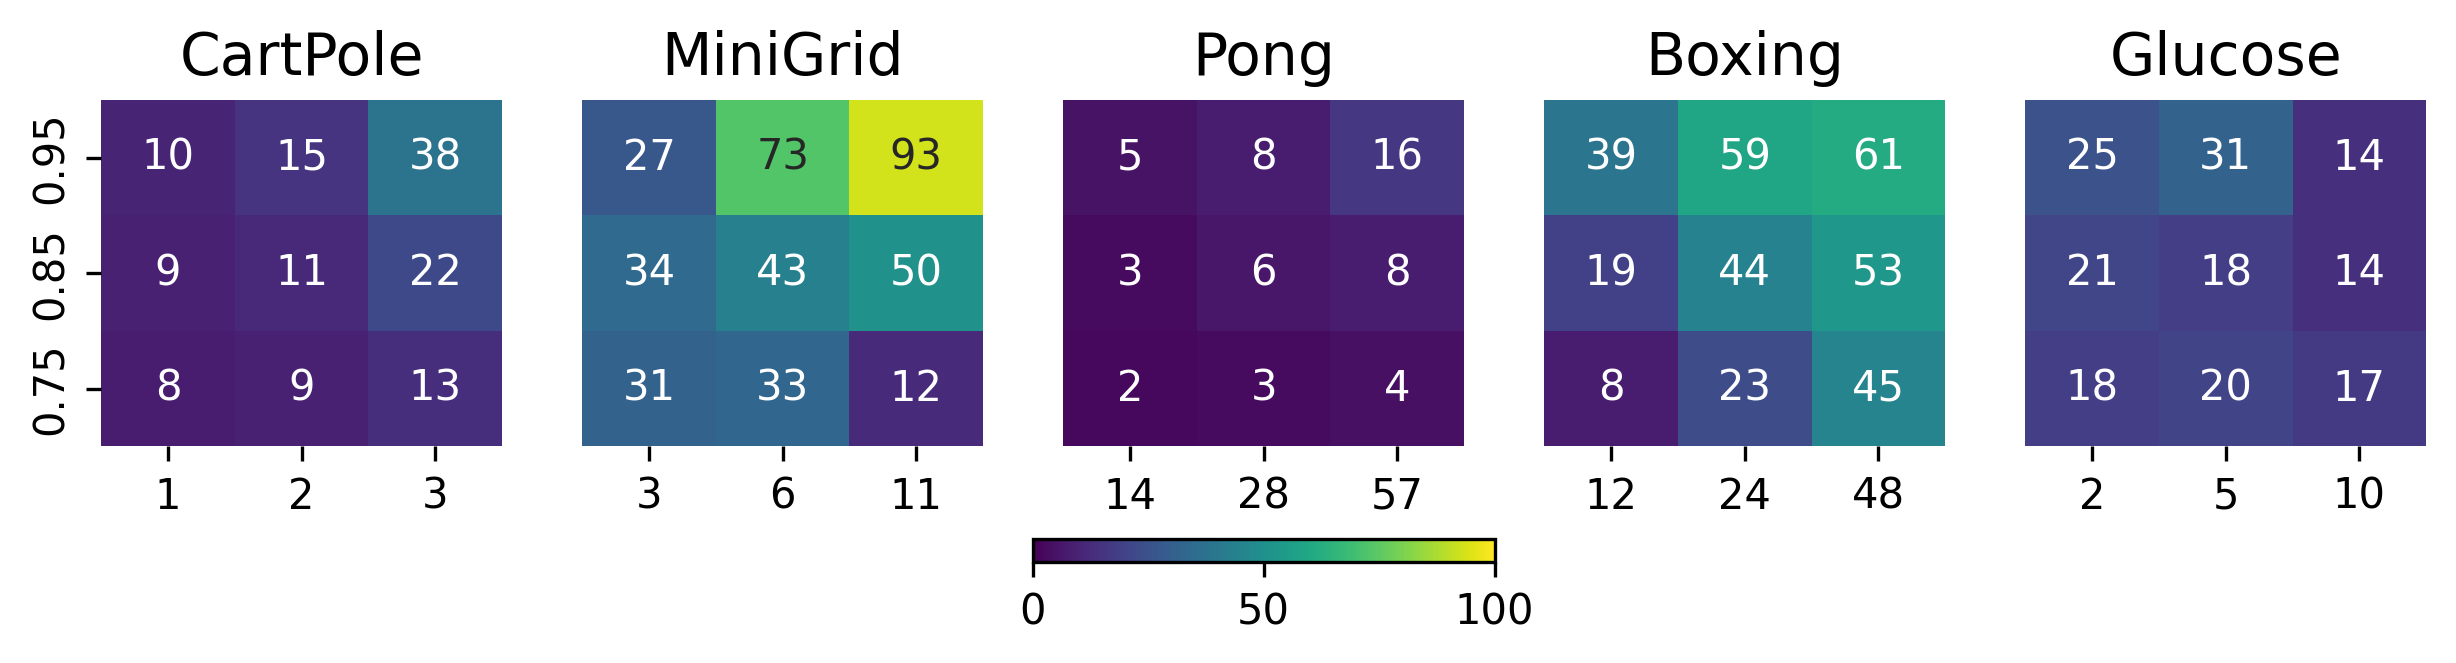

In [43]:
plot_dimensions = (1,len(perfect_environments))
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(len(perfect_environments))] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = [[name_to_nice[i] for i in perfect_environments]]
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

import matplotlib as mpl

fig, ax = create_axes(plot_dimensions, overall_format, titles=titles)

# Draw all heatmaps WITHOUT colorbars
for i in range(len(perfect_environments)):
    annot = accuracies 
    if i!=0:
        annot = [] 
    sns.heatmap(
        heatmap_by_env[i],
        ax=ax[0][i],
        cmap="viridis",
        xticklabels=num_concepts_selected[i],
        yticklabels=annot,
        vmin=0, vmax=100,   # ensure consistent scaling
        cbar=False,
        annot=True
    )
    ax[0][i].invert_yaxis()

# ---- GLOBAL HORIZONTAL COLORBAR (0 to 1) ----
norm = mpl.colors.Normalize(vmin=0, vmax=100)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[a for row in ax for a in row],
    orientation='horizontal',
    fraction=0.05,    # thinner bar
    pad=0.20          # spacing from subplots
)

fig.savefig(
    "../../results/figures/num_concepts_accuracy.pdf",
    dpi=300,
    bbox_inches='tight')


In [44]:
num_concepts_selected = 11
concept_accuracies = [0.75,0.85,0.95]
environment = "mini_grid"
rewards = []

for acc in concept_accuracies:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': num_concepts_selected, 'concept_accuracy':acc, 'training_timesteps': t})
        print(acc,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
    rewards.append(temp)
rewards_accuracy = np.array(rewards)

0.75 250000 3
0.75 500000 3
0.75 750000 3
0.75 1000000 3
0.85 250000 3
0.85 500000 3
0.85 750000 3
0.85 1000000 3
0.95 250000 3
0.95 500000 3
0.95 750000 3
0.95 1000000 3


In [45]:
acc = 0.9
num_concepts_selected = [3,6,11]
environment = "mini_grid"
total_concepts = 44
rewards = []

for n in num_concepts_selected:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': n, 'concept_accuracy':0.95, 'training_timesteps': t})
        print(n,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
    rewards.append(temp)
rewards_num_concepts = np.array(rewards)
rewards_num_concepts

3 250000 3
3 500000 3
3 750000 3
3 1000000 3
6 250000 3
6 500000 3
6 750000 3
6 1000000 3
11 250000 3
11 500000 3
11 750000 3
11 1000000 3


array([[10.57174097, 27.46907345, 32.98550754, 35.64520518],
       [38.25154443, 72.95475303, 77.62362377, 79.57873018],
       [71.92803478, 93.42016578, 93.91971068, 94.16691514]])

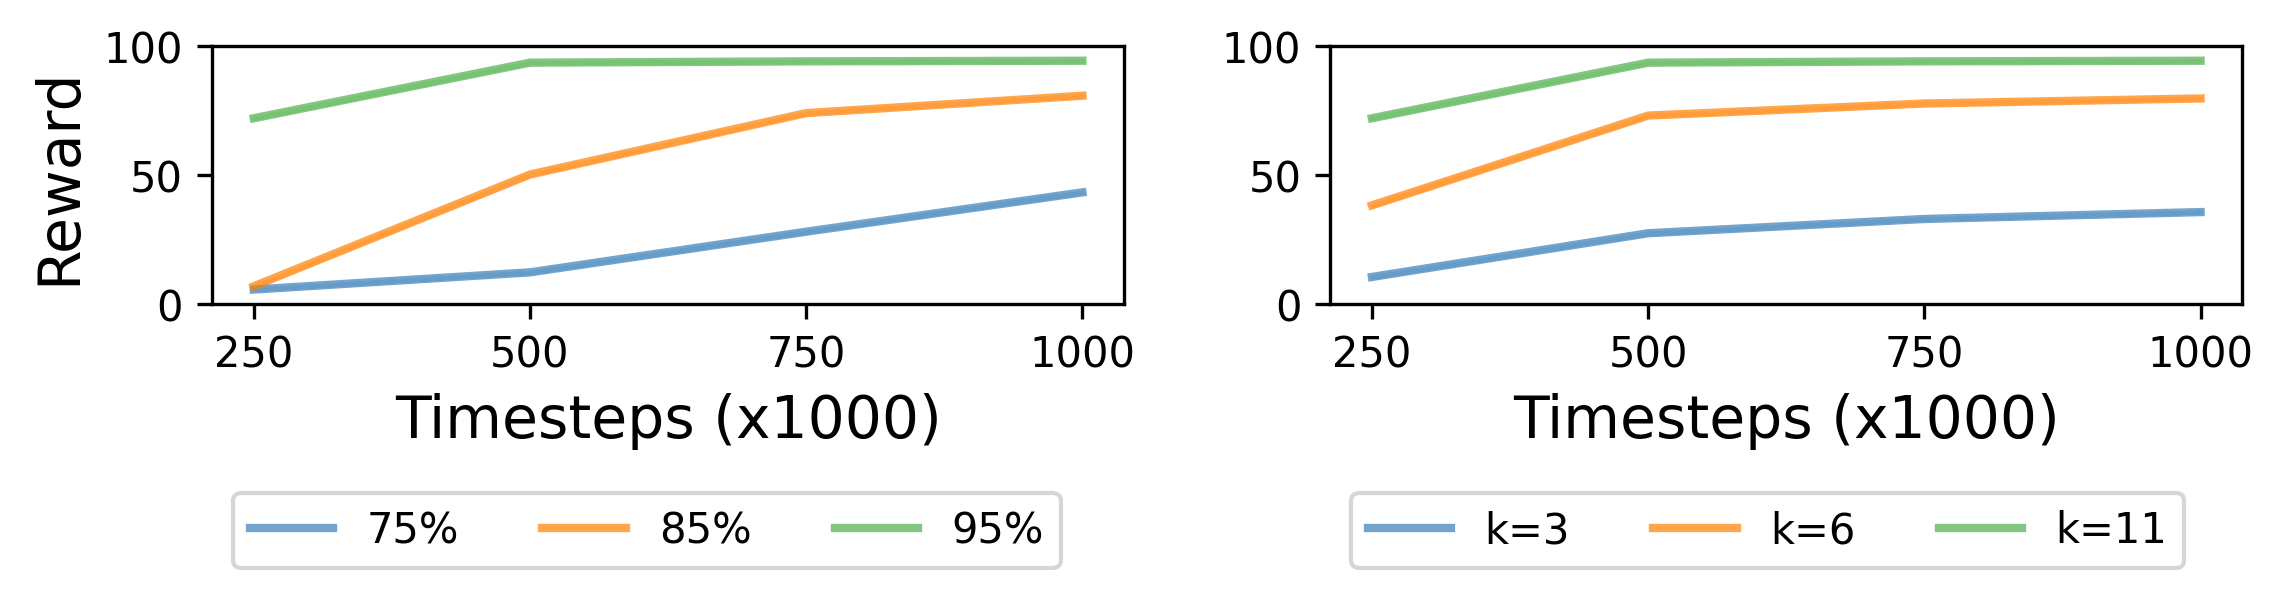

In [46]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,2)
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(2)] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res


sup_y_label = ""
overall_format = {'figsize':(8,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[[0,1,2,3],["250","500","750","1000"]] for i in range(2)]],
    'y_ticks': [[[[0,50,100],["0","50","100"]] for i in range(2)]],
    'y_lim': [[[0,100] for i in range(2)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,y_labels=[["Reward",""]],x_labels=[["Timesteps (x1000)","Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_accuracy
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][0],x_groups,y_vals,y_std,["{}%".format(round(i*100)) for i in concept_accuracies],line_format)

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_num_concepts 
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][1],x_groups,y_vals,y_std,["k={}".format(i) for i in num_concepts_selected],line_format)


legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0,-1.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/accuracy_num_concepts.pdf",dpi=300, bbox_inches='tight')

In [47]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]

intervention_probability = [0.25,0.5,0.75]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

cart_pole_interventions = []
e = "cart_pole"
cart_pole_interventions.append(all_performances_imperfect[0][1:])
for i in intervention_probability:
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': i})
        if len(matching_params) > 0:
            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)
        else:
            temp.append(0.0001)
    cart_pole_interventions.append(temp)
intervention_probability.append(1.0)
intervention_probability = [0.0] + intervention_probability
cart_pole_interventions.append(all_performances_perfect[0][1:])

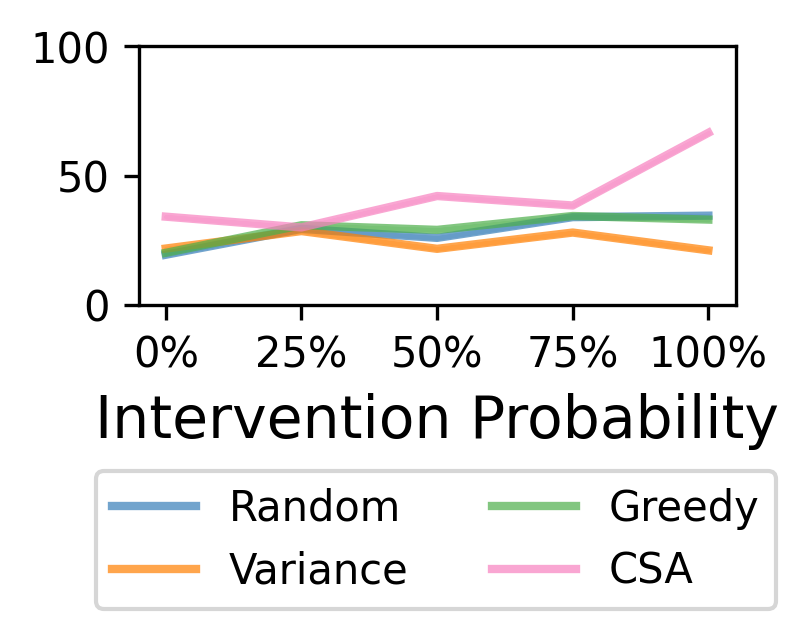

In [49]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [[""]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),["0%","25%","50%","75%","100%"]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Intervention Probability"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(len(intervention_probability))) for j in imperfect_methods]
y_vals = np.array(cart_pole_interventions).T
y_std = np.zeros(y_vals.shape)
plot_line(ax[0][0],x_groups,y_vals,y_std,['Random','Variance','Greedy','CSA'],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 2, 'bbox_to_anchor': (0.15,-0.15),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_percent.pdf",dpi=300, bbox_inches='tight')


In [50]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]

intervention_probability = [0.25,0.5,0.75]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

cart_pole_interventions = []
e = "cart_pole"
cart_pole_interventions.append(all_performances_imperfect[0][1:])
for i in intervention_probability:
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': i})
        if len(matching_params) > 0:
            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)
        else:
            temp.append(0.0001)
    cart_pole_interventions.append(temp)
intervention_probability.append(1.0)
intervention_probability = [0.0] + intervention_probability
cart_pole_interventions.append(all_performances_perfect[0][1:])

# Common parameters
intervention_probability = [0.25, 0.5, 0.75]
num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

# ============================================
# CART POLE DATA
# ============================================
e = 'cart_pole'
matching_params = get_results_matching_parameters("intervention", "", {
    'environment_string': e,
    'training_timesteps': training_times[e],
    'num_concepts_selected': num_concepts_selected[e],
    'method': 'multiple', 
    'intervention_prob': 0.5
})
accuracies = np.array(matching_params[0]['concept_accuracy'])

selected_concepts = []
for m in imperfect_methods:
    matching_params = get_results_matching_parameters("intervention", "", {
        'environment_string': e,
        'training_timesteps': training_times[e],
        'num_concepts_selected': num_concepts_selected[e],
        'method': m, 
        'intervention_prob': 0.5
    })
    selected_concepts.append(matching_params[0][m]['concepts'])

baseline_accuracies_cp = [accuracies[i] for i in selected_concepts]
intervention_accuracies_cp = []
for i in intervention_probability:
    intervention_accuracies_cp.append([(i)*np.ones(3) + (1-i)*j for j in baseline_accuracies_cp])
intervention_accuracies_cp = np.array(intervention_accuracies_cp)
intervention_accuracies_cp = np.mean(intervention_accuracies_cp, axis=2)
baseline_accuracies_cp = [np.mean(i) for i in baseline_accuracies_cp]

cart_pole_intervention_performance = cart_pole_interventions[2]
cart_pole_baseline_performance = cart_pole_interventions[0]

baseline_combo_cp = np.array(list(zip(baseline_accuracies_cp, cart_pole_baseline_performance)))
intervention_combo_cp = np.array(list(zip(intervention_accuracies_cp[1], cart_pole_intervention_performance)))
# ============================================
# BOXING DATA
# ============================================
cart_pole_interventions_boxing = []
e = "boxing"

intervention_probability_boxing = [0.0,0.25, 0.5, 0.75]
for i in intervention_probability_boxing:
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention", "", {
            'environment_string': e,
            'training_timesteps': 2000000,
            'num_concepts_selected': num_concepts_selected[e],
            'method': m, 
            'intervention_prob': i,
        })
        if len(matching_params) > 0:
            performance = method_scales[3](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)
        else:
            temp.append(0.0001)
    cart_pole_interventions_boxing.append(temp)

intervention_probability_boxing.append(1.0)
intervention_probability_boxing = [0.0] + intervention_probability_boxing
cart_pole_interventions_boxing.append(all_performances_perfect[0][1:])

# Recompute for boxing with same concept selection
e = 'boxing'  # Note: This seems intentional based on your original code
matching_params = get_results_matching_parameters("intervention", "", {
    'environment_string': e,
    'num_concepts_selected': num_concepts_selected[e],
    'intervention_prob': 0.5,
    'method': 'multiple'
})
accuracies = 1-(2*(1-np.array(matching_params[0]['concept_accuracy'])))

selected_concepts = []
for m in imperfect_methods:
    matching_params = get_results_matching_parameters("intervention", "", {
        'environment_string': e,
        'training_timesteps': 2_000_000,
        'num_concepts_selected': num_concepts_selected[e],
        'method': m, 
        'intervention_prob': 0.5, 
    })

    print(len(matching_params))
    if len(matching_params) > 0:
        selected_concepts.append(matching_params[0][m]['concepts'])
    else:
        selected_concepts.append([0])

baseline_accuracies_boxing = [accuracies[i] for i in selected_concepts]
intervention_accuracies_boxing = []
intervention_probability_calc = [0.25, 0.5, 0.75]
for i in intervention_probability_calc:
    intervention_accuracies_boxing.append([(i)*np.ones(48) + (1-i)*j for j in baseline_accuracies_boxing])
intervention_accuracies_boxing = np.array(intervention_accuracies_boxing)
intervention_accuracies_boxing = np.mean(intervention_accuracies_boxing, axis=2)
baseline_accuracies_boxing = [np.mean(i) for i in baseline_accuracies_boxing]

cart_pole_intervention_performance_boxing = cart_pole_interventions_boxing[2]
cart_pole_baseline_performance_boxing = cart_pole_interventions_boxing[0]

baseline_combo_boxing = np.array(list(zip(baseline_accuracies_boxing, cart_pole_baseline_performance_boxing)))
intervention_combo_boxing = np.array(list(zip(intervention_accuracies_boxing[1], cart_pole_intervention_performance_boxing)))


3
3
3
3


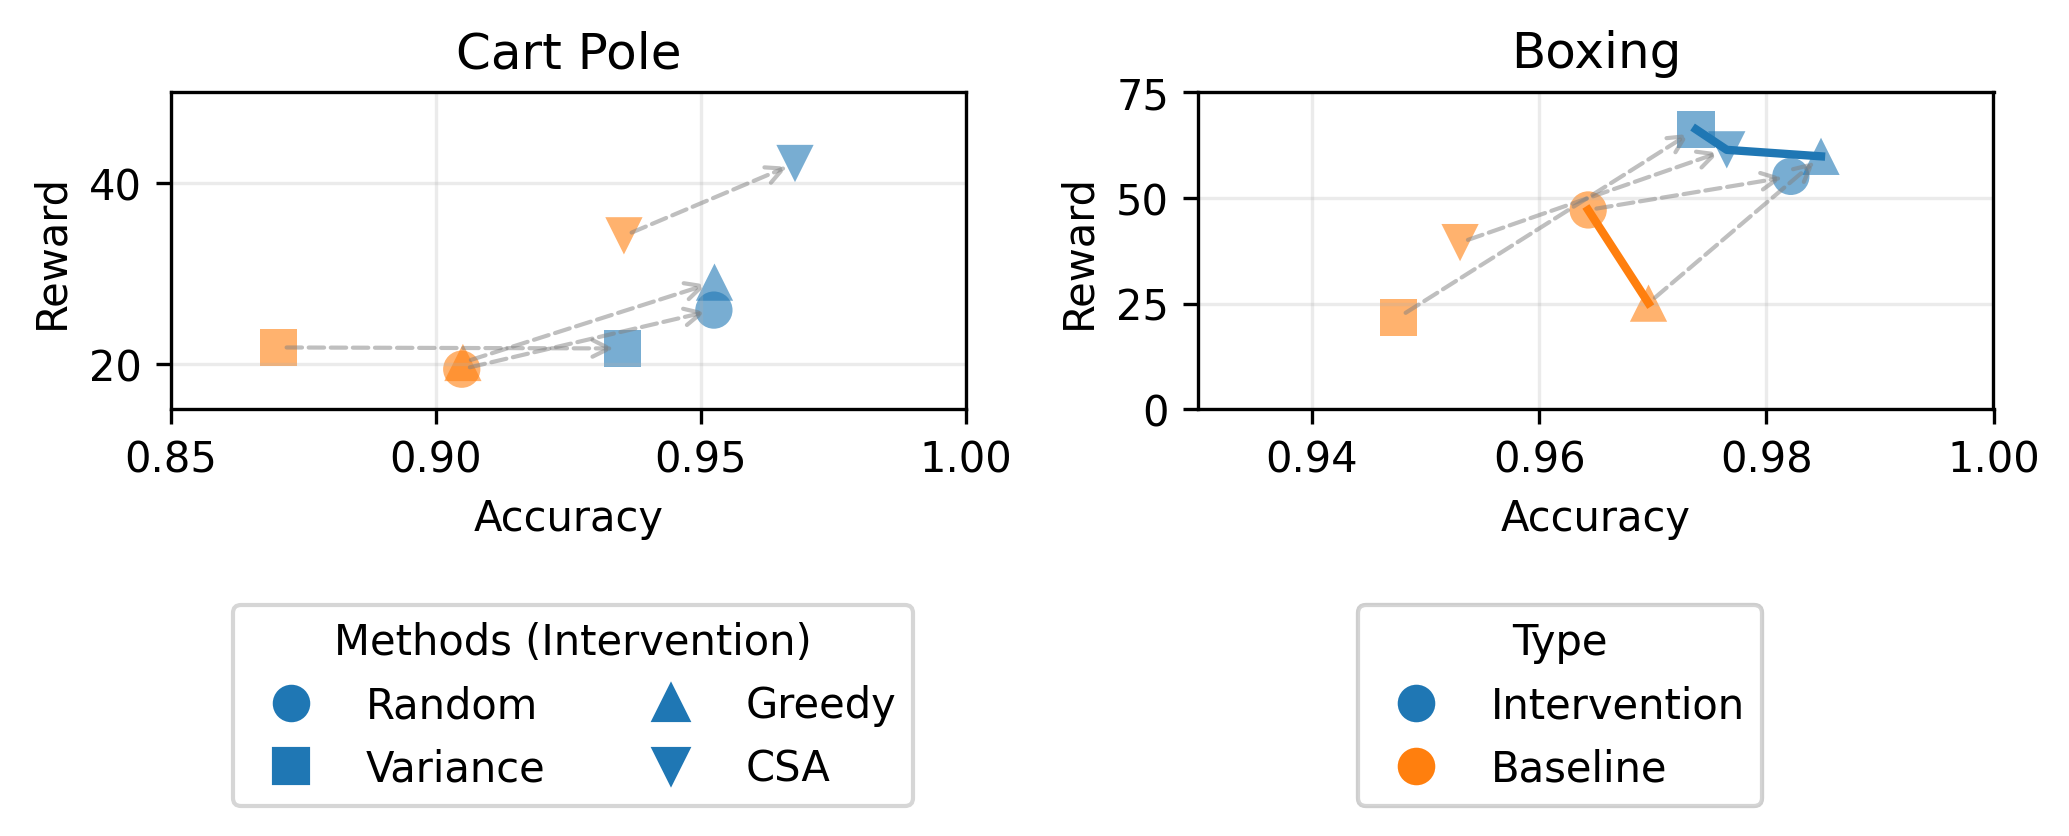

In [77]:
def pareto_front(points):
    """Compute Pareto front (maximize x, minimize y)"""
    pts = points[points[:,0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] >= front[-1][1]:
            front.append(p)
    return np.array(front)

def plot_intervention_comparison(ax, baseline_combo, intervention_combo, title, xlim, ylim):
    """Plot intervention comparison on given axis"""
    markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', '<', '>']
    
    # Scatter plots
    for i, (x, y) in enumerate(intervention_combo):
        ax.scatter(x, y, marker=markers[i % len(markers)], s=80, alpha=0.6, 
                   edgecolors='none', color='C0')
    
    for i, (x, y) in enumerate(baseline_combo):
        ax.scatter(x, y, marker=markers[i % len(markers)], s=80, alpha=0.6, 
                   edgecolors='none', color='C1')
    
    # Pareto fronts
    intervention_pf = pareto_front(intervention_combo)
    baseline_pf = pareto_front(baseline_combo)
    
    ax.plot(intervention_pf[:,0], intervention_pf[:,1], linewidth=2, label='Intervention Pareto')
    ax.plot(baseline_pf[:,0], baseline_pf[:,1], linewidth=2, label='Baseline Pareto')
    
    # Connecting arrows
    for (x_b, y_b), (x_i, y_i) in zip(baseline_combo, intervention_combo):
        ax.annotate("", xy=(x_i, y_i), xytext=(x_b, y_b),
                    arrowprops=dict(arrowstyle="->", linestyle="--", 
                                    color="gray", alpha=0.5, linewidth=1))
    
    # Formatting
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Reward")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title)
    ax.grid(alpha=0.25)

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 2))

# Plot Cart Pole
plot_intervention_comparison(ax1, baseline_combo_cp, intervention_combo_cp, 
                             'Cart Pole', [0.85, 1.0], [15, 50])

# Plot Boxing
plot_intervention_comparison(ax2, baseline_combo_boxing, intervention_combo_boxing, 
                             'Boxing', [0.93, 1.0], [0, 75])


# --- 1) Color legend: Intervention vs Baseline ---
color_handles = [
    mlines.Line2D([], [], color='C0', marker='o', linestyle='None', markersize=8, label='Intervention'),
    mlines.Line2D([], [], color='C1', marker='o', linestyle='None', markersize=8, label='Baseline')
]

# Place the color legend
color_legend = fig.legend(handles=color_handles, title="Type", loc="upper center",
                          bbox_to_anchor=(0.75,0), ncol=1, frameon=True)

# --- 2) Marker legend: Methods (Intervention) ---
method_names = ['Random', 'Variance', 'Greedy', 'CSA']
markers = ['o', 's', '^', 'v']

method_handles = [
    mlines.Line2D([], [], color='C0', marker=markers[i], linestyle='None', markersize=8, label=method_names[i])
    for i in range(len(method_names))
]

# Place the marker legend below the color legend
method_legend = fig.legend(handles=method_handles, title="Methods (Intervention)",
                           loc="upper center", bbox_to_anchor=(0.28, 0), ncol=2,
                           frameon=True)

# Make sure both legends appear
fig.add_artist(color_legend)

plt.tight_layout()
plt.savefig("../../results/figures/intervention_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [78]:
gold_timesteps = [100000,250000,500000]
methods = ["greedy","lp_hybrid"]
e = "mini_grid"

performance_by_gold = []
for m in methods:
    temp = []
    for g in gold_timesteps:
        matching_params = get_results_matching_parameters("ablations","",{'environment_string': e,'gold_timesteps':g,
                                                                    'method': m})
        if len(matching_params) > 0:
            val = method_scales[1](np.mean([i[m]['reward'] for i in matching_params]))
        else:
            val = 0
        temp.append(val)
    performance_by_gold.append(temp)
np.array(performance_by_gold)

array([[48.44095232, 47.94062803, 60.05950556],
       [91.81564678, 93.26298131, 94.4886942 ]])

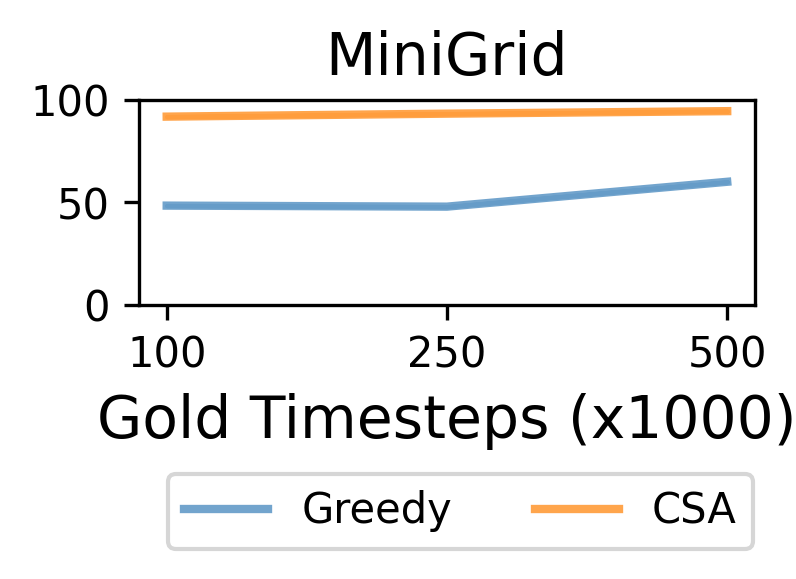

In [82]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [["MiniGrid"]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(gold_timesteps))),[str(g//1000) for g in gold_timesteps]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Gold Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(3)) for j in range(2)]
y_vals = np.array(performance_by_gold)
y_std = np.zeros(y_vals.shape)
plot_line(ax[0][0],x_groups,y_vals,y_std,["Greedy","CSA"],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.23,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/gold_timesteps.pdf",dpi=300, bbox_inches='tight')

In [83]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","lp_hybrid","policy_selection_lp","lp_old","completeness","lp_policy"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","lp_hybrid","policy_selection_lp","lp_old","completeness","lp_policy"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_perfect_lp = []
all_performances_imperfect_lp = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)
    all_performances_perfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        if m == 'multiple':
            print("Environment",e,[i['concept_accuracy'] for i in matching_params])

    all_performances_imperfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison'})
    matching_params = [i for i in matching_params if 'ground_truth' in i]
    performance = method_scales[j](np.mean([i['ground_truth']['reward'] for i in matching_params]))
    all_baselines.append(performance)
all_baselines.append(0)

TypeError: list indices must be integers or slices, not str

5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


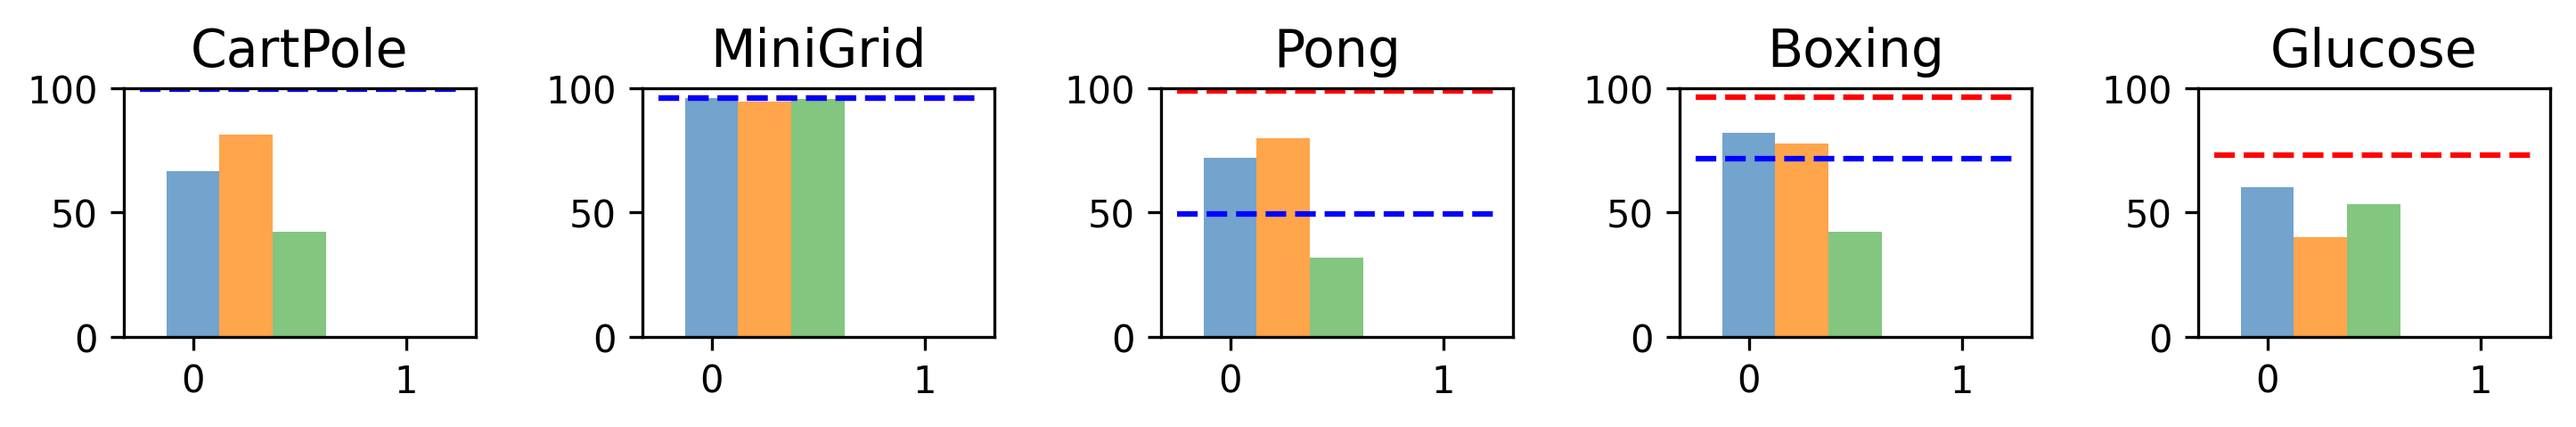

In [56]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect_lp[i][:-1])))
    y_vals = all_performances_perfect_lp[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], {
        0: 'LP',
        1: 'Policy-LP',
        2: 'Q-LP',
        3: 'Completeness',
        4: 'LP Policy'
    },bar_format)
    
    ax[0][i].hlines(all_performances_perfect_lp[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/perfect_other_methods.pdf",dpi=300, bbox_inches='tight')

5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


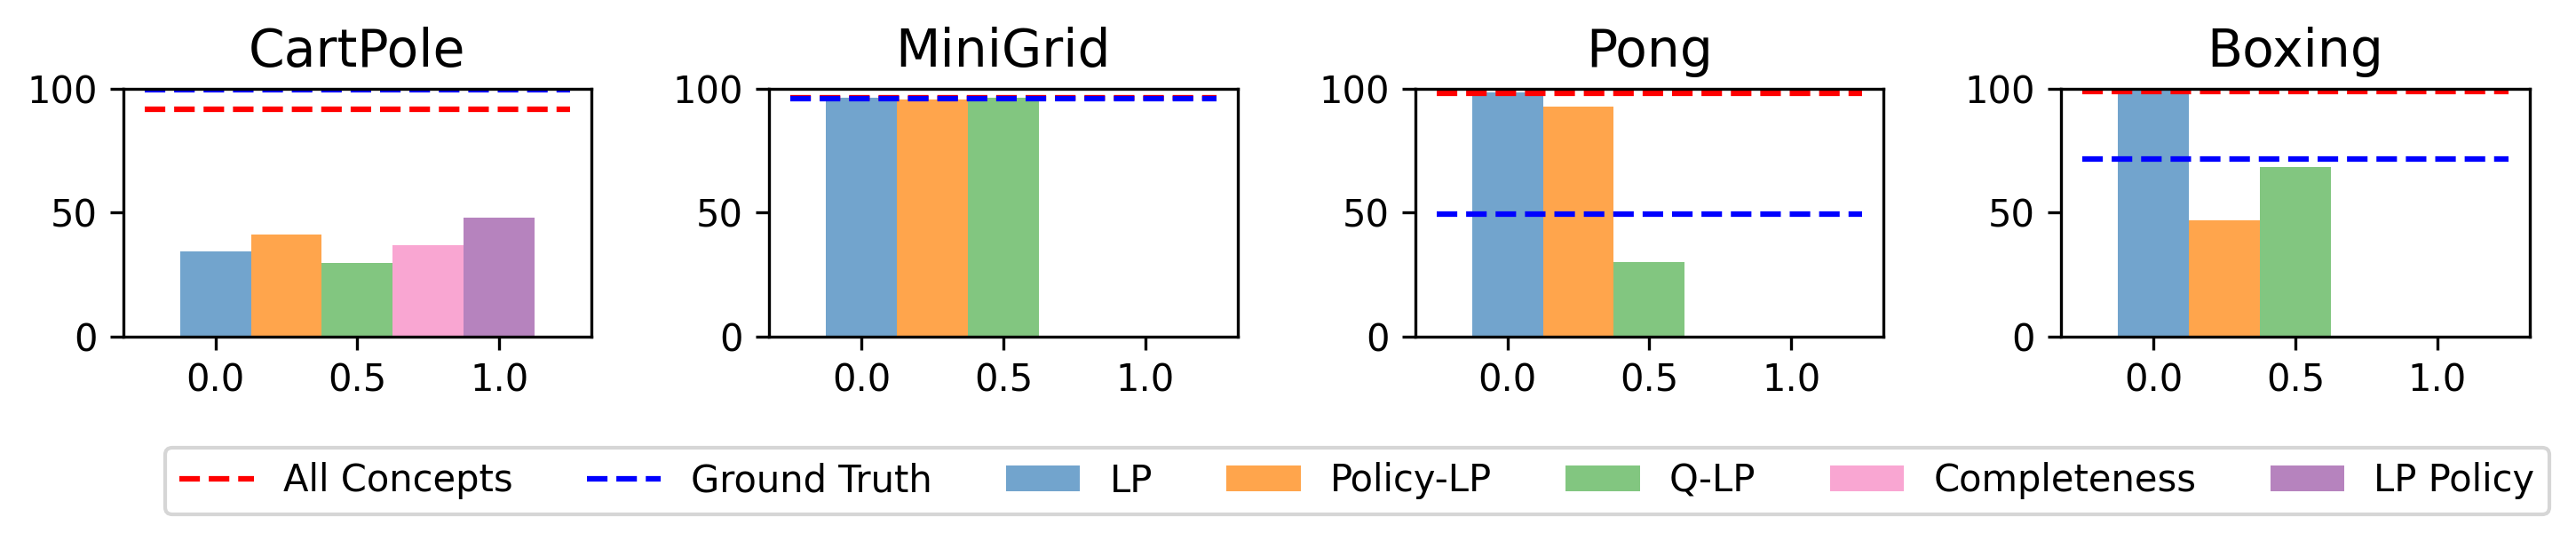

In [57]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect_lp[i][:-1])))
    y_vals = all_performances_imperfect_lp[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))],  {
        0: 'LP',
        1: 'Policy-LP',
        2: 'Q-LP',
        3: 'Completeness',
        4: 'LP Policy'
    },bar_format)
    
    ax[0][i].hlines(all_performances_imperfect_lp[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.075,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_other_methods.pdf",dpi=300, bbox_inches='tight')

In [29]:
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': 311})
matching_params = [i for i in matching_params if 'epochs' not in i['parameters']]
perfect_lp = [[m['perfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
chosen_concepts = np.mean([m['perfect']['manual']['reward'] for m in matching_params])
similarity = [[len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
perfect_lp = np.mean(perfect_lp,axis=0)
similarity = np.mean(similarity,axis=1)

In [30]:
imperfect_lp = [[m['imperfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
imperfect_lp = np.mean(imperfect_lp,axis=0)
multiple_lp = [[m['imperfect']['multiple'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
multiple_lp = np.mean(multiple_lp,axis=0)

greedy = [[m['imperfect']['greedy'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
greedy = np.mean(greedy,axis=0)

random_selection = [[m['imperfect']['random'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
random_selection = np.mean(random_selection,axis=0)


chosen_concepts = np.mean([m['imperfect']['manual']['reward'] for m in matching_params])


In [31]:
similarity_multiple = [[len(set(m['imperfect']['multiple'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_random= [[len(set(m['imperfect']['random'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_greedy= [[len(set(m['imperfect']['greedy'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity = [[len(set(m['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]

similarity_multiple = np.mean(similarity_multiple,axis=1)
similarity_random = np.mean(similarity_random,axis=1)
similarity_greedy = np.mean(similarity_greedy,axis=1)
similarity = np.mean(similarity,axis=1)

In [32]:
imperfect_lp_intervention = [[m['intervention']['lp'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
imperfect_lp_intervention = np.mean(imperfect_lp_intervention,axis=0)
multiple_lp_intervention = [[m['intervention']['multiple'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
multiple_lp_intervention = np.mean(multiple_lp_intervention,axis=0)

greedy_intervention = [[m['intervention']['greedy'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
greedy_intervention = np.mean(greedy_intervention,axis=0)

random_selection_intervention = [[m['intervention']['random'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
random_selection_intervention = np.mean(random_selection_intervention,axis=0)


chosen_concepts_intervention = [[m['intervention']['manual'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
chosen_concepts_intervention = np.mean(chosen_concepts_intervention,axis=0)


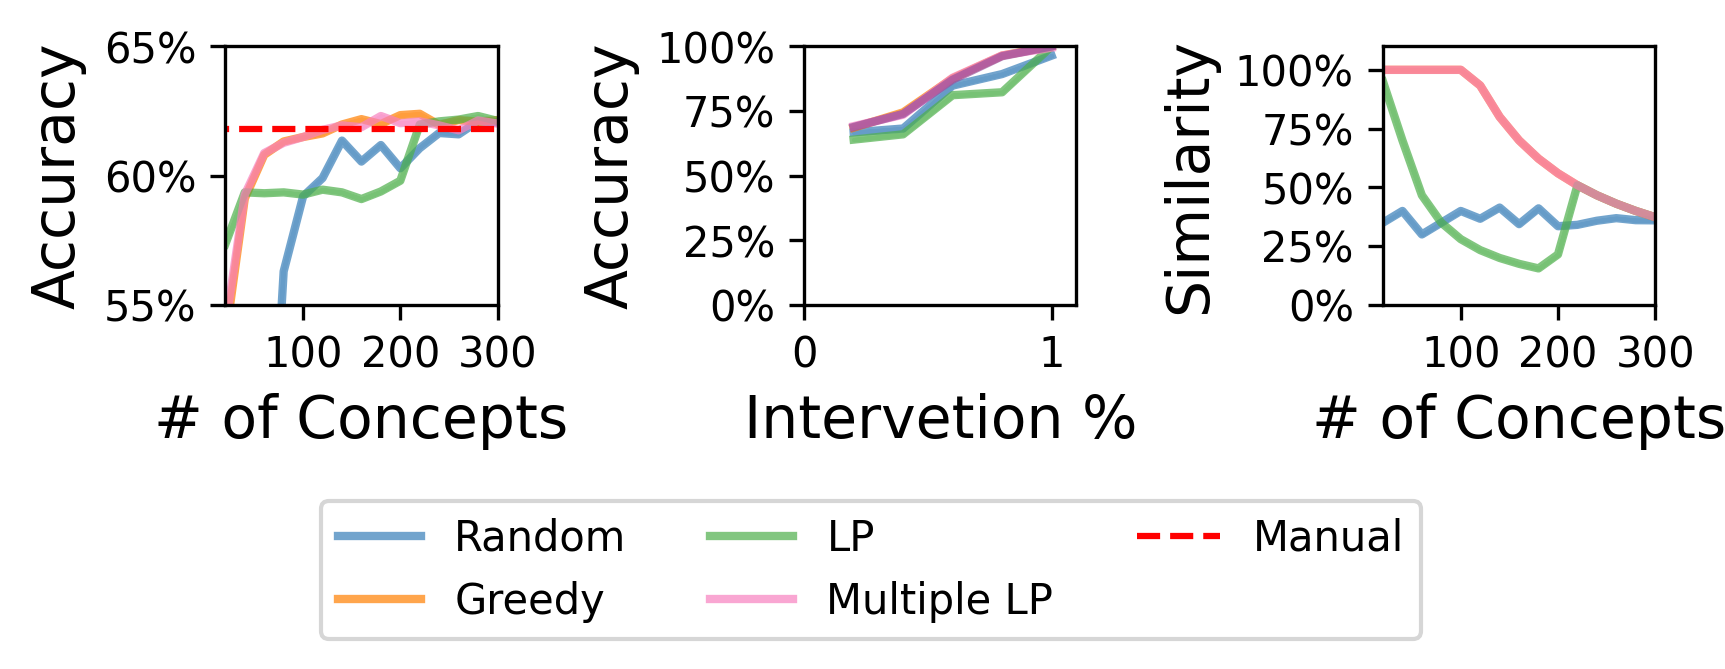

In [33]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,3)

sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_lim': [[[20,300],[0,1.1],[20,300]]],
    'y_lim': [[[0.55,0.65],[0,1],[0,1.1]]],
    'y_ticks': [[[[0.55,0.6,0.65],["55%","60%","65%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts","Intervetion %","# of Concepts"]],y_labels=[["Accuracy","Accuracy","Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Random","Greedy","LP","Multiple LP"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection,greedy,imperfect_lp,multiple_lp]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
ax[0][0].hlines(chosen_concepts,0,311,label="Manual",color="red",linestyle="--")
line_format = {'color_palette': 'six_color', 'linewidth': 2}

all_labels = ["Random","Greedy","LP","Multiple LP","Manual"]

x_groups = [[0.2,0.4,0.6,0.8,1.0] for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection_intervention,greedy_intervention,imperfect_lp_intervention,multiple_lp_intervention,chosen_concepts_intervention]]

plot_line(ax[0][1],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)


all_labels = ["Random","Greedy","LP","Multiple LP"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(similarity)-1)] for i in range(len(x_groups[0]))] for arr in [similarity_random,similarity_greedy,similarity,similarity_multiple]]

plot_line(ax[0][2],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.2,-0.2),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')